In [85]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,SAMPLING_DIR,PLOTS_DIR,PREDICTIONS_DIR,RAW_DIR

In [86]:
import ternary
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [87]:
from models_scripts.gp_workflow import ExperimentalGPApproach

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength
from data.splitting import DataSplitter
from data.preprocessing import prepare_train_test
from data.Descriptors import AlloyDescriptorCalculator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

Data extraction

In [88]:
import pandas as pd

df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")

# --- Merge full data ---
df_merged = merge_data(df_optical, df_comp)

# -------------------------------
# Extract pure compositions
# -------------------------------
pure_ids = [29, 30, 31]

df_pure = df_merged[df_merged["ID"].isin(pure_ids)].copy()
df_no_pure = df_merged[~df_merged["ID"].isin(pure_ids)].copy()

# -------------------------------
# Main dataframe for splitting
# -------------------------------
tern_1550 = filter_by_wavelength(df_no_pure, 1550).copy()
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[["ID", "resistivity"]])

X = tern_1550[["Cu", "Ni", "Al", "resistivity"]].copy()
y = tern_1550["e2"].copy()

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="cluster",
    n_clusters=8
)

split_dict = splitter.split(X, y)

# -------------------------------
# Add pure metals back to training
# -------------------------------
pure_1550 = filter_by_wavelength(df_pure, 1552.0).copy()
pure_1550 = merge_data(pure_1550, df_resis_ANN[["ID", "resistivity"]])

X_pure = pure_1550[["Cu", "Ni", "Al", "resistivity"]].copy()
y_pure = pure_1550["e2"].copy()

split_dict["X_train"] = pd.concat([split_dict["X_train"], X_pure], ignore_index=True)
split_dict["y_train"] = pd.concat([split_dict["y_train"], y_pure], ignore_index=True)

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [14]:
# New compositions
new_comp = pd.DataFrame({
    "Cu": [0, 0.02,0.1,0.16,0.35,0.52,0.92,0.24,0.24,0.3,0.3,0.46,0.46,0.1,0.4,0.4,0.5,0.5],
    "Ni": [0.02,0.64,0.5,0.34,0.35,0,0.02,0.3,0.46,0.24,0.46,0.24,0.3,0.4,0.1,0.5,0.4,0.1],
    "Al": [0.98,0.34,0.4,0.5,0.3,0.48,0.06,0.46,0.3,0.46,0.24,0.3,0.24,0.5,0.5,0.1,0.1,0.4]
})

In [89]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [90]:
e2_predict_ER_model = pd.read_pickle(PREDICTIONS_DIR / "ANN_Predictions/ANN_e2_calculated.pkl")
e2_predict_ER_model = e2_predict_ER_model[['Cu','Ni','Al','e2']]
ann_model = e2_predict_ER_model.sort_values(by="e2")

In [102]:
df_std = pd.read_csv("df_std_first.csv")

In [92]:
df1_top = ann_model.head(25)
df2_top = df_std.head(50)
df_combined = pd.concat([df1_top, df2_top], axis=0)
new_comp = df_combined.drop_duplicates(subset=["Cu", "Ni", "Al"])

In [104]:
import numpy as np
import pandas as pd

def select_sparse_points(df, score_col, n_select=10, min_dist=8):
    """
    Select top points by score, but enforce minimum distance in composition space.
    
    Parameters
    ----------
    df : DataFrame
        Must contain columns Cu, Ni, Al and score_col
    score_col : str
        Column used to rank candidates
    n_select : int
        Number of points to select
    min_dist : float
        Minimum Euclidean distance in composition space
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    
    selected_idx = []
    selected_points = []

    for i, row in df.iterrows():
        p = row[["Cu", "Ni", "Al"]].values.astype(float)

        if len(selected_points) == 0:
            selected_idx.append(i)
            selected_points.append(p)
        else:
            dists = [np.linalg.norm(p - q) for q in selected_points]
            if min(dists) >= min_dist:
                selected_idx.append(i)
                selected_points.append(p)

        if len(selected_idx) >= n_select:
            break

    return df.loc[selected_idx].reset_index(drop=True)

In [105]:
import numpy as np
import pandas as pd

def remove_close_to_existing(candidates, existing, min_dist=8):
    """
    Remove candidate points that are too close to already existing/performed points.

    Parameters
    ----------
    candidates : pd.DataFrame
        Must contain columns ['Cu', 'Ni', 'Al']
    existing : pd.DataFrame
        Must contain columns ['Cu', 'Ni', 'Al']
    min_dist : float
        Minimum Euclidean distance allowed

    Returns
    -------
    pd.DataFrame
        Filtered candidates
    """
    candidates = candidates.copy().reset_index(drop=True)
    existing_points = existing[["Cu", "Ni", "Al"]].values.astype(float)

    keep = []

    for _, row in candidates.iterrows():
        p = row[["Cu", "Ni", "Al"]].values.astype(float)

        dists = np.linalg.norm(existing_points - p, axis=1)
        keep.append(dists.min() >= min_dist)

    return candidates[keep].reset_index(drop=True)

In [161]:
df1_clean = remove_close_to_existing(df_std, X, min_dist=1)
df2_clean = remove_close_to_existing(ann_model, X, min_dist=1)

In [162]:
sel1 = select_sparse_points(df_std, score_col="std", n_select=35, min_dist=0.1)
sel2 = select_sparse_points(ann_model, score_col="e2", n_select=15, min_dist=0.1)

In [146]:
sel1.head(5)

,Cu,Ni,Al,std
0,0.00,0.24,0.76,19.411402
1,0.00,0.76,0.24,19.251812
2,0.16,0.00,0.84,18.482537
3,0.84,0.00,0.16,18.262218
4,0.08,0.86,0.06,18.072413


In [163]:
df_combined = pd.concat([sel1, sel2], axis=0)
new_comp = df_combined.drop_duplicates(subset=["Cu", "Ni", "Al"])

In [164]:
new_comp.shape

(50, 5)

In [166]:
new_comp.to_excel("Tenary_round2.xlsx", index=False)

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


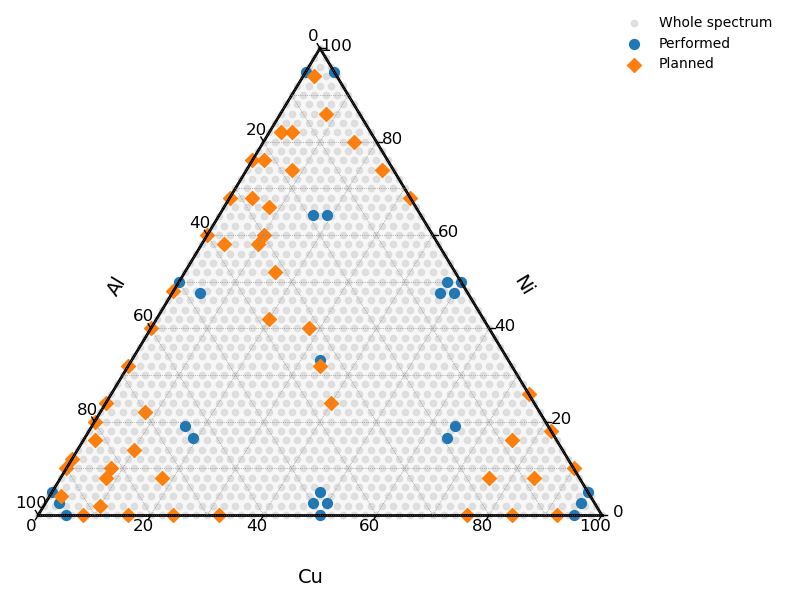

In [165]:
import ternary
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
# whole composition space
space = comp_space[['Cu', 'Ni', 'Al']].copy()

# already performed
performed = X.drop(columns='resistivity')[['Cu', 'Ni', 'Al']].copy()

# planned next
planned = new_comp[['Cu', 'Ni', 'Al']].copy()

# -----------------------------
# Normalize rows to sum to 100
# -----------------------------
def norm_rows(df):
    arr = np.asarray(df, dtype=float)
    s = arr.sum(axis=1, keepdims=True)
    s[s == 0] = 1.0
    return arr / s * 100.0

space_n = norm_rows(space)
performed_n = norm_rows(performed)
planned_n = norm_rows(planned)

# convert to tuples for python-ternary
pts_space = [tuple(p) for p in space_n]
pts_performed = [tuple(p) for p in performed_n]
pts_planned = [tuple(p) for p in planned_n]

# -----------------------------
# Plot
# -----------------------------
scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

# whole spectrum / all compositions
tax.scatter(
    pts_space,
    marker="o",
    s=20,
    color="#d9d9d9",
    alpha=0.8,
    label="Whole spectrum"
)

# performed compositions
tax.scatter(
    pts_performed,
    marker="o",
    s=50,
    color="#1f77b4",
    alpha=1,
    label="Performed"
)

# planned compositions
tax.scatter(
    pts_planned,
    marker="D",
    s=50,
    color="#ff7f0e",
    alpha=1,
    label="Planned"
)

tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=10)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=12)

tax.left_axis_label("Al", fontsize=14, offset=0.12)
tax.right_axis_label("Ni", fontsize=14, offset=0.12)
tax.bottom_axis_label("Cu", fontsize=14, offset=0.06)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)

plt.show()

In [84]:
new_comp.to_excel("Tenary_round2.xlsx", index=False)

In [68]:
filtered_candidates = remove_close_to_existing(
    candidates=new_comp,
    existing=X,
    min_dist=10
)

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


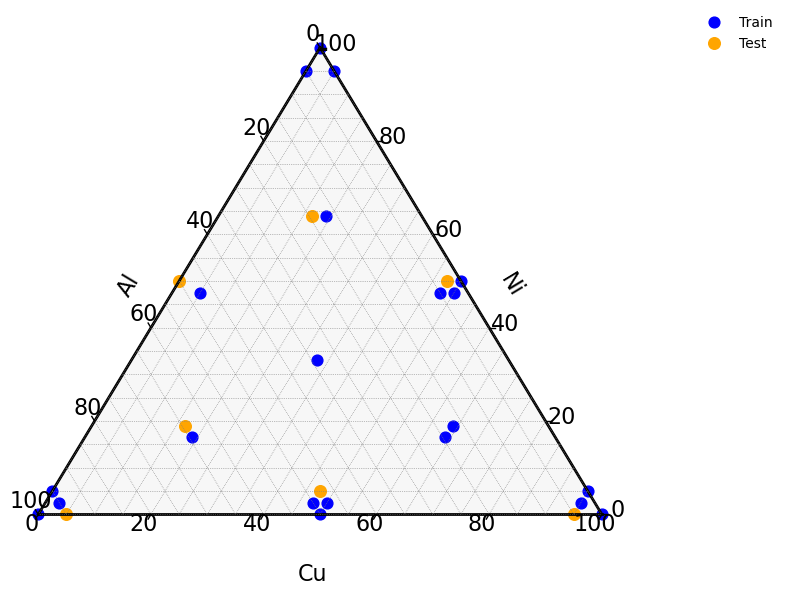

In [8]:
train_comp_cluster = np.asarray(split_dict['X_train'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(split_dict['X_test'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)

In [4]:
#========= Experimental compositions ================
db = DatabaseManager(DATABASE_DIR/"Ternary_round1.db")

df_optical = db.table_dataframe('Optical_properties')
df_comp = db.table_dataframe('compositions')
db.close()

df_merged = df_optical.merge(df_comp, on="ID", how="inner")
tern_1550 = df_merged[np.isclose(df_merged["wavelength_nm"].astype(float), 1552.0)]

# ============== Descriptors ======================================= #
atomic_radius = pd.read_pickle(DESCRIPTORS_DIR/"Atomic_radius.pkl")
electronegativity = pd.read_pickle(DESCRIPTORS_DIR/"electronegativity.pkl")
valence_electrons = pd.read_pickle(DESCRIPTORS_DIR/"Valence_electrons.pkl")

atomic_radius = atomic_radius.set_index("symbol")
electronegativity = electronegativity.set_index("Symbol")
valence_electrons = valence_electrons.set_index("symbol")

atomic_radius = atomic_radius.rename(columns={"Metallic": "atomic_radius"})
valence_electrons = valence_electrons.rename(columns={"valence": "valence_electrons"})

elem_props = (
    atomic_radius
    .join(electronegativity)
    .join(valence_electrons)
)

calc = AlloyDescriptorCalculator(elem_props=elem_props)
df_ternary_1f_properties = calc.add_all_descriptors(tern_1550[['Cu','Ni','Al']])

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [5]:
comp_columns = ["Cu", "Ni", "Al"]

df_ternary_1f_properties = df_ternary_1f_properties.merge(
    tern_1550[comp_columns + ["e1", "e2"]],
    on=comp_columns,
    how="left"
)

All space prediction

In [6]:
#========= Predicted Compositions ================
db = DatabaseManager(DATABASE_DIR/"Calculate_EMA.db")

df_optical_all = db.table_dataframe('Optical_properties')
df_comp_all = db.table_dataframe('compositions')
db.close()

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Calculate_EMA.db
Database connection closed


In [7]:
df_space = calc.add_all_descriptors(df_comp_all[['Cu','Ni','Al']])
df_space.to_csv(RAW_DIR/"CuNiAl_descriptors.csv", index=False)

Random Sampling

In [8]:
DP = DataPreprocessor()
X = df_ternary_1f_properties[['Cu','Ni','Al']]
y = df_ternary_1f_properties['e2']

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="random"
)

data_split = splitter.split_training(X, y)

with open(SAMPLING_DIR/"random_split", "wb") as f:
    pickle.dump(data_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


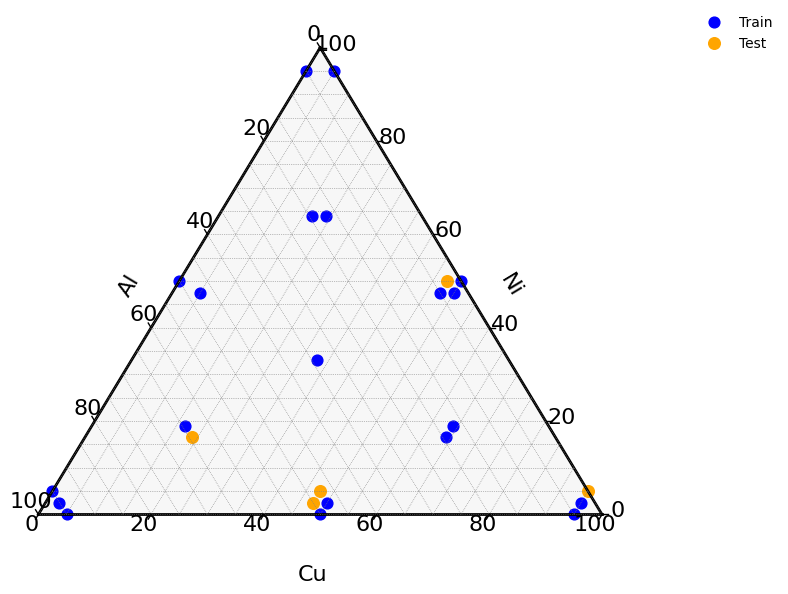

In [9]:
train_comp = np.asarray(data_split['X_train_split'][['Cu','Ni','Al']]*100)
test_comp = np.asarray(data_split['X_test_split'][['Cu','Ni','Al']]*100)

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp, scale)
pts_B = to_ternary_points(test_comp, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
#plt.show()
plt.savefig(PLOTS_DIR/"Random_Sampling.svg", format="svg", bbox_inches="tight")

Sampling using clustering

In [ ]:
X_numpy = np.asarray(X, dtype=float)
y_numpy = np.asarray(y, dtype=float)

X_n2 = X_numpy[:,3:]

k = 6 # clusters number
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_n2)

train_idx = []
test_idx = []

for c in np. unique(clusters):
    clusters_indices = np.where(clusters == c)[0]
    
    tr, te = train_test_split(
        clusters_indices,
        test_size=0.15,
        random_state=42
        )
    train_idx.extend(tr)
    test_idx.extend(te)
    
train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train_cluster = X.iloc[train_idx].copy()
X_test_cluster = X.iloc[test_idx].copy()

y_train_cluster = y.iloc[train_idx].copy()
y_test_cluster = y.iloc[test_idx].copy()

cluster_split = {}
cluster_split['X_train_split'] = X_train_cluster
cluster_split['X_test_split'] = X_test_cluster
cluster_split['y_train'] = y_train_cluster
cluster_split['y_test'] = y_test_cluster

with open(SAMPLING_DIR/"cluster_split", "wb") as f:
    pickle.dump(cluster_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


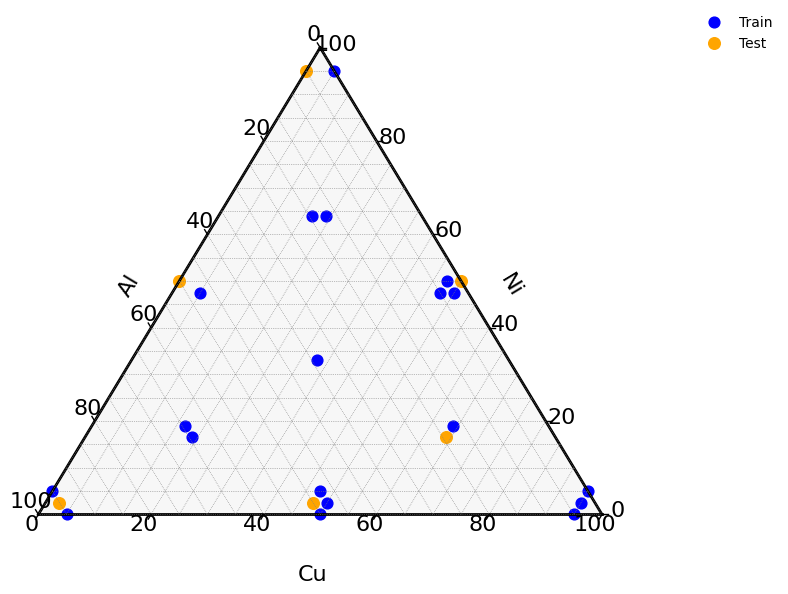

In [10]:
splitter = DataSplitter(
    test_size=0.05,
    random_state=42,
    split_method="cluster",
    n_clusters =6,
    cluster_feature_start= 0
)

cluster_split = splitter.split_training(X, y)

with open(SAMPLING_DIR/"cluster_split", "wb") as f:
    pickle.dump(cluster_split, f)


train_comp_cluster = np.asarray(cluster_split['X_train_split'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(cluster_split['X_test_split'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
plt.savefig(PLOTS_DIR/"Cluster_kmeans_Sampling.svg", format="svg", bbox_inches="tight")


Previous splitting

In [68]:
train_comp = pd.read_csv(PREDICTIONS_DIR/"ANN_Predictions/train_exp_comp")
test_comp = pd.read_csv(PREDICTIONS_DIR/"ANN_Predictions/test_exp_comp")


In [69]:
comp_columns = ["Cu", "Ni", "Al"]
features_columns = ['r','del_r','del_EN','S','VEC']
property = ['e2']


train_comp_2 = train_comp.merge(
    df_ternary_1f_properties[comp_columns + features_columns],
    on=comp_columns,
    how="left"
)

train_e2 = train_comp.merge(
    df_ternary_1f_properties[comp_columns+property],
    on=comp_columns,
    how="left"
)

test_comp_2 = test_comp.merge(
    df_ternary_1f_properties[comp_columns + features_columns],
    on=comp_columns,
    how="left"
)

test_e2 = test_comp.merge(
    df_ternary_1f_properties[comp_columns+property],
    on=comp_columns,
    how="left"
)


cluster_split = {}
cluster_split['X_train_split'] = train_comp_2[comp_columns+features_columns]
cluster_split['X_test_split'] = test_comp_2[comp_columns+features_columns]
cluster_split['y_train'] = train_e2['e2']
cluster_split['y_test'] = test_e2['e2']

with open(SAMPLING_DIR/"cluster_split", "wb") as f:
    pickle.dump(cluster_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


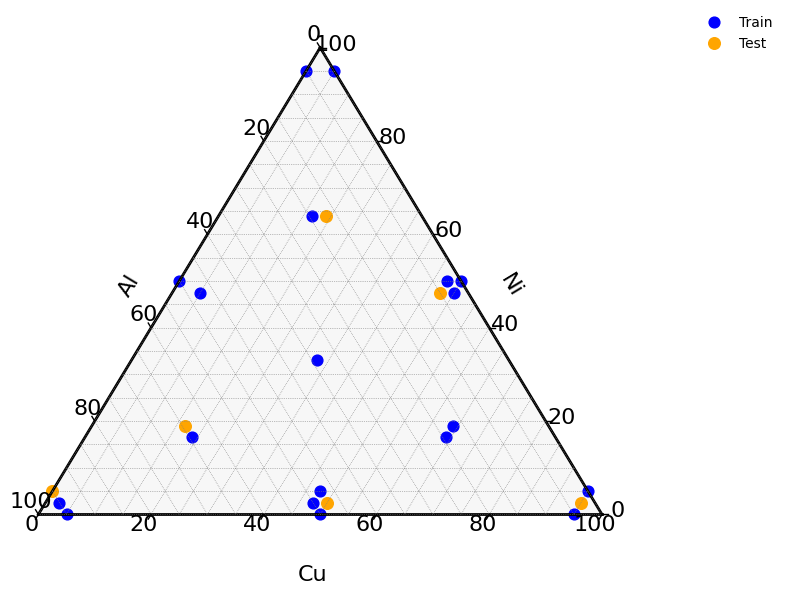

In [50]:
train_comp_cluster = np.asarray(cluster_split['X_train_split'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(cluster_split['X_test_split'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
plt.savefig(PLOTS_DIR/"Cluster_kmeans_Sampling.svg", format="svg", bbox_inches="tight")